# Modelo Random Forest

## Paso 1: Importación de Librerías y Carga de Datos

Comenzamos cargando las herramientas necesarias y los datos que ya fueron limpiados, divididos y balanceados (con SMOTE) por el pipeline oficial del equipo.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, accuracy_score, classification_report
import optuna
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# 1. Cargamos los datos finales ya procesados por Isa
X_train = pd.read_csv('../data/processed/X_train_final.csv')
y_train = pd.read_csv('../data/processed/y_train_final.csv')['target_tipo_ui']

X_test = pd.read_csv('../data/processed/X_test_final.csv')
y_test = pd.read_csv('../data/processed/y_test_final.csv')['target_tipo_ui']

print(f"X_train shape (con SMOTE): {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape (con SMOTE): (15540, 23)
X_test shape: (1815, 23)


## Paso 2: Modelo Base (Baseline) y Validación Cruzada



In [ ]:
# Inicializamos Random Forest base con class_weight='balanced'
rf_baseline = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Definimos Validación Cruzada Estratificada para que evalúe 5 veces
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluamos el modelo usando F1-Macro
cv_results = cross_validate(rf_baseline, X_train, y_train, cv=skf, scoring='f1_macro')

baseline_f1_macro = cv_results['test_score'].mean()
print(f"Baseline Random Forest - F1-Macro promedio (CV 5-fold): {baseline_f1_macro:.4f}")

## 3. Optimización con Optuna

In [ ]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = RandomForestClassifier(**params)
    score = cross_validate(model, X_train, y_train, cv=skf, scoring='f1_macro')
    
    return score['test_score'].mean()

# Creamos el estudio Optuna para maximizar el F1-Macro
study = optuna.create_study(direction='maximize', study_name="RF_Optimization")
study.optimize(rf_objective, n_trials=30)

print(f"\nMejor F1-Macro CV: {study.best_value:.4f}")
print("Mejores parámetros:", study.best_params)

## 4. Comparación: Baseline vs Modelo Afinado

In [ ]:
# Probamos el Baseline original contra el 20% del Test final
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)
baseline_test_f1 = f1_score(y_test, y_pred_baseline, average='macro')

# Construimos y entrenamos el Modelo Tuneado con los parámetros de Optuna
best_params = study.best_params
rf_tuned = RandomForestClassifier(
    **best_params, 
    class_weight='balanced',
    random_state=42, 
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

# Lo enfrentamos también al Test final
y_pred_tuned = rf_tuned.predict(X_test)
tuned_test_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print("=== RENDIMIENTO EVALUADO EN EL SET DE PRUEBA (TEST) ===")
print(f"Test Baseline F1-Macro:  {baseline_test_f1:.4f}")
print(f"Test Tuneado (Optuna):   {tuned_test_f1:.4f}")
print(f"Diferencia en Score:     {tuned_test_f1 - baseline_test_f1:.4f}")

## 5. Importancia de Variables (Feature Importances)

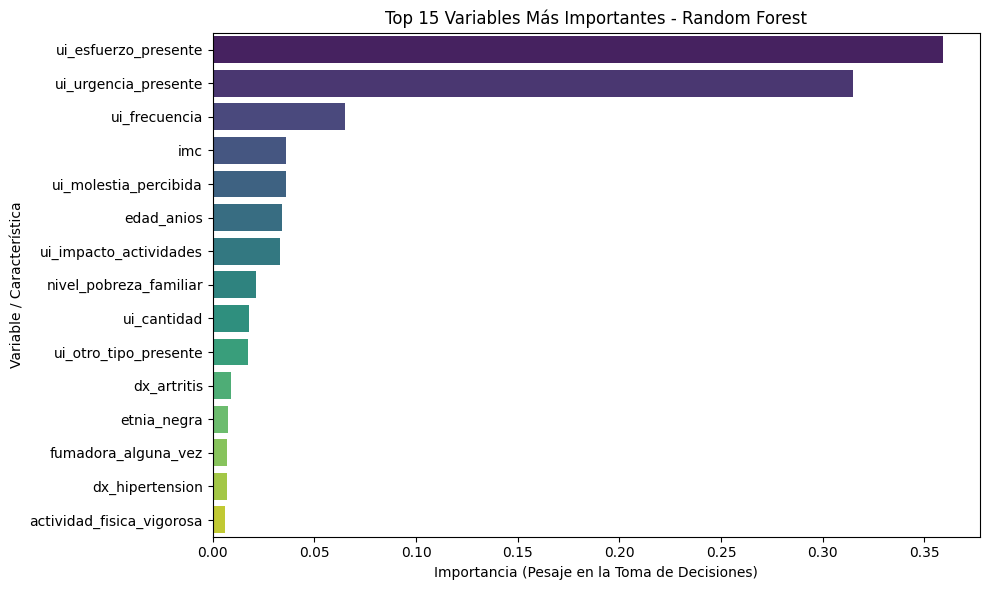

In [10]:
# Obtenemos el peso real (matemático) que le dio el bosque a cada columna
importances = rf_tuned.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Variables Más Importantes - Random Forest')
plt.xlabel('Importancia (Pesaje en la Toma de Decisiones)')
plt.ylabel('Variable / Característica')
plt.tight_layout()
plt.show()

## 6. Métricas Finales: Accuracy, F1-Macro, Precision y Recall por Clase

In [11]:
from sklearn.metrics import precision_score, recall_score

# Métricas globales
acc = accuracy_score(y_test, y_pred_tuned)
f1_mac = f1_score(y_test, y_pred_tuned, average='macro')
prec_mac = precision_score(y_test, y_pred_tuned, average='macro')
rec_mac = recall_score(y_test, y_pred_tuned, average='macro')

print("=== MÉTRICAS GLOBALES (Modelo Tuneado) ===")
print(f"Accuracy:        {acc:.4f}")
print(f"F1-Macro:        {f1_mac:.4f}")
print(f"Precision-Macro: {prec_mac:.4f}")
print(f"Recall-Macro:    {rec_mac:.4f}")

print("\n=== REPORTE POR CLASE ===")
print(classification_report(y_test, y_pred_tuned))

=== MÉTRICAS GLOBALES (Modelo Tuneado) ===
Accuracy:        0.9416
F1-Macro:        0.9378
Precision-Macro: 0.9168
Recall-Macro:    0.9631

=== REPORTE POR CLASE ===
              precision    recall  f1-score   support

       mixed       0.92      1.00      0.96       328
        none       0.99      0.90      0.94       972
      stress       0.89      0.99      0.94       317
        urge       0.86      0.96      0.91       198

    accuracy                           0.94      1815
   macro avg       0.92      0.96      0.94      1815
weighted avg       0.95      0.94      0.94      1815



## 7. Guardar Modelo 

In [ ]:
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_tuned, '../models/random_forest.pkl')
print("Modelo guardado en models/random_forest.pkl")